<a href="https://colab.research.google.com/github/SMM303/Displacement-Analysis-/blob/main/displacement_governance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Displacement Governance Analysis: Conflict and Disaster Patterns, 2008-2025

**Author:** Saleh Mansour
**Data sources:** IDMC Internal Displacement (Conflict-Violence-Disasters) country-year dataset (2008-2024), IDMC GIDD Disaggregated event-level dataset (2025), INFORM Risk Index trend panel (2017-2026)

This notebook runs the full analytical pipeline for the three sub-questions defined in the research design:

1. **Concentration** — regional and hazard/conflict-subtype clustering of 2025 displacement events.
2. **Data reliability as a governance signal** — confidence-level coverage and the housing-destruction proxy audit.
3. **Structural moderation over time** — fixed-effects panel regression of displacement flow on INFORM's Hazard, Vulnerability, and Coping Capacity pillars, 2017-2024.

Every numeric claim in the output cells is computed from the uploaded files, not assumed. Row-count validation runs immediately after upload so a corrupted or mismatched file is caught before any analysis proceeds.

Visualisation choices follow Munzner's effectiveness ranking of visual channels (position and length first, then angle/area, colour reserved for categorical identity with a small number of hues), and avoid channels known to be low-effectiveness for quantitative comparison (3-D, unordered colour for ordered data, area-only encodings for precise reading).

## Section 0 — Environment setup

In [149]:
import subprocess, sys

LIBS = ["shap", "plotly", "kaleido", "openpyxl", "Pillow"]
for lib in LIBS:
    subprocess.check_call([sys.executable, "-m", "pip", "install", lib, "-q"])
    print(f"  ✅  {lib} ready")

# ─── Import everything ────────────────────────────────────────────────────────
import warnings, gc, os, json
from pathlib import Path
from datetime import datetime
from io import BytesIO

import numpy        as np
import pandas       as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn      as sns
import plotly.express as px
import shap

from scipy import stats
from sklearn.ensemble        import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.cluster         import KMeans
from sklearn.decomposition   import PCA
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, roc_curve, classification_report,
    ConfusionMatrixDisplay, silhouette_score
)
from PIL import Image # Added PIL Image
from IPython.display import display # Added display for PIL images

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'font.family': 'DejaVu Sans'})

# ─── Output folders ───────────────────────────────────────────────────────────
OUT  = Path("displacement_outputs")
FIGS = OUT / "figures"
OUT.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

def save_fig(name):
    # Ensure a .tif extension
    base_name, _ = os.path.splitext(name)
    tiff_name = f"{base_name}.tif"
    file_path = FIGS / tiff_name

    fig = plt.gcf()
    current_width_inches, _ = fig.get_size_inches()

    # Calculate dpi needed for at least 1500 pixels width
    min_pixel_width = 1500
    if current_width_inches > 0:
        required_dpi_for_width = min_pixel_width / current_width_inches
    else:
        # Fallback if width is zero or unreasonable, use a default high dpi
        required_dpi_for_width = 150

    # Use a minimum DPI of 150 or the calculated one if higher
    final_dpi = max(150, int(required_dpi_for_width))

    plt.savefig(file_path, bbox_inches='tight', dpi=final_dpi, format='tiff')
    print(f"   💾  Chart saved → figures/{tiff_name}")
    display_grayscale_from_path(file_path) # Call helper function here

# Helper function to display grayscale version of a saved image
def display_grayscale_from_path(file_path):
    if not file_path.exists():
        print(f"  ⚠️  File not found: {file_path}. Cannot generate grayscale.")
        return

    print(f"  🖼️  Generating grayscale for {file_path.name} ...")
    try:
        img = Image.open(file_path)
        grayscale_img = img.convert('L')
        display(grayscale_img)
        print(f"  ✅  Grayscale version displayed for {file_path.name}.")
    except Exception as e:
        print(f"  ❌  Error processing {file_path.name} for grayscale: {e}")

print("\n✅  STEP 1 COMPLETE — All libraries loaded and output folders created.")

  ✅  shap ready
  ✅  plotly ready
  ✅  kaleido ready
  ✅  openpyxl ready
  ✅  Pillow ready

✅  STEP 1 COMPLETE — All libraries loaded and output folders created.


In [150]:
import importlib
import subprocess
import sys

REQUIRED = [
    "pandas", "numpy", "scipy", "statsmodels", "linearmodels",
    "scikit-learn", "matplotlib", "seaborn", "plotly", "openpyxl",
    "kaleido",
]

def ensure_installed(packages):
    for pkg in packages:
        import_name = {
            "scikit-learn": "sklearn",
        }.get(pkg, pkg.replace("-", "_"))
        try:
            importlib.import_module(import_name)
        except ImportError:
            # If plotly is being installed, make sure to upgrade it to a compatible version for kaleido
            if pkg == "plotly":
                subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg, "--upgrade"], check=True)
            else:
                subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

ensure_installed(REQUIRED)
print("Environment ready.")

Environment ready.


In [151]:
# Section 0.2 — Imports
import io
import re
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
from linearmodels.panel import PanelOLS

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

from sklearn.cluster import DBSCAN

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# Consistent visual style applied throughout (Munzner-aligned defaults):
# - sequential/qualitative palettes chosen deliberately per chart, never the Matplotlib default cycle
# - gridlines light and behind data, never competing with data ink
# - no 3-D projections anywhere in this notebook
sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "0.3",
    "axes.grid": True,
    "grid.color": "0.88",
    "grid.linewidth": 0.6,
    "font.size": 11,
})
FIGDIR = Path("/content/figures")
OUTDIR = Path("/content/output")
FIGDIR.mkdir(parents=True, exist_ok=True)
OUTDIR.mkdir(parents=True, exist_ok=True)
print("Imports complete. Figures will be written to", FIGDIR, "and cleaned data to", OUTDIR)


Imports complete. Figures will be written to /content/figures and cleaned data to /content/output


## Section 1 — Data upload

Three source workbooks are required, in their original multi-sheet `.xlsx` form (not the flattened `.md` exports, since the sheet structure is what the code below relies on):

1. `IDMC_Internal_Displacement_Conflict-Violence_Disasters.xlsx`
2. `IDMC_GIDD_Internal_Displacement_Disaggregated.xlsx`
3. `INFORM2026_TREND_2017_2026_v72_ALL.xlsx`

Run the cell below in Colab. It will prompt for each file in turn with a file picker. If the notebook is not running in Colab, it falls back to asking for a local file path, so the same notebook also runs unmodified in a local Jupyter environment.

In [152]:
# ─── This cell opens a file upload dialog in Google Colab ─────────────────────
# from google.colab import files as colab_files

# print("📂 Please upload all three Excel files when the dialog opens ...")
# print("   (You can select multiple files at once with Ctrl+Click or Cmd+Click)")
# print()

# uploaded = colab_files.upload()

# # ─── Confirm what was uploaded ────────────────────────────────────────────────
# print(f"\n  Files received ({len(uploaded)}):")
# FILE_PATHS = {}
# for fname, data in uploaded.items():
#     size_mb = len(data) / 1e6
#     print(f"  ✅  {fname}  ({size_mb:.1f} MB)")
#     # Save to disk so we can read with pandas
#     with open(fname, 'wb') as f:
#         f.write(data)
#     FILE_PATHS[fname] = fname

# ─── Identify which file is which ─────────────────────────────────────────────
# FILE_GIDD     = next((k for k in FILE_PATHS if 'GIDD' in k or 'Disaggregated' in k), None)
# FILE_MAIN     = next((k for k in FILE_PATHS if 'Conflict' in k and 'Disasters' in k), None)
# FILE_INFORM   = next((k for k in FILE_PATHS if 'INFORM' in k), None)

path_gidd     = "https://docs.google.com/spreadsheets/d/1WFq5mukqG0PkOf1ud-KJhB5Gq1UVQxXP/export?format=xlsx"
# IMPORTANT: This path needs to be updated to a multi-year IDMC dataset (2008-2024)
# If using a Google Sheet, replace YOUR_MULTI_YEAR_DATA_SPREADSHEET_ID with the actual ID:
# path_conflict_disaster     = "https://docs.google.com/spreadsheets/d/YOUR_MULTI_YEAR_DATA_SPREADSHEET_ID/export?format=xlsx" # Placeholder for multi-year data
# If using a local uploaded file (e.g., from a previous `colab_files.upload()` or mounted drive):
path_conflict_disaster     = "IDMC_Internal_Displacement_Conflict-Violence_Disasters.xlsx"
path_inform   = "https://docs.google.com/spreadsheets/d/1ZEcTtB-3W-SNq_no0Ponz8a2Y95JoiQk/export?format=xlsx"

print(f"\n  IDMC Disaggregated  → {path_gidd}")
print(f"  IDMC Main Table     → {path_conflict_disaster}")
print(f"  INFORM Risk Index   → {path_inform}")

if not all([path_gidd, path_conflict_disaster, path_inform]):
    print("\n  ⚠️  WARNING: Could not identify all three files.")
    print("     Please check filenames and re-run this cell.")
else:
    print("\n✅  STEP 2 COMPLETE — All files uploaded successfully.")


  IDMC Disaggregated  → https://docs.google.com/spreadsheets/d/1WFq5mukqG0PkOf1ud-KJhB5Gq1UVQxXP/export?format=xlsx
  IDMC Main Table     → IDMC_Internal_Displacement_Conflict-Violence_Disasters.xlsx
  INFORM Risk Index   → https://docs.google.com/spreadsheets/d/1ZEcTtB-3W-SNq_no0Ponz8a2Y95JoiQk/export?format=xlsx

✅  STEP 2 COMPLETE — All files uploaded successfully.


### Action Required: Re-run cells from Section 2 onwards

Now that the `path_conflict_disaster` variable has been updated to point to a multi-year dataset, please re-run all cells from **Section 2 (`4ca15844`) onwards**.

This will ensure that the `panel` DataFrame is correctly rebuilt with the multi-year data, which is essential for resolving the `ZeroDivisionError` in the PanelOLS regressions.

## Section 2 — Load and validate

Row counts are checked against the known structure of each workbook. A mismatch does not stop execution, it prints a warning, because a legitimate data refresh from IDMC or INFORM will change these counts over time. The point is to catch silent truncation or a wrong file, not to hard-code a permanent expectation.

In [153]:
# Section 2.1 — Load all sheets
xl_cd = pd.ExcelFile(path_conflict_disaster)
df_stock   = pd.read_excel(xl_cd, sheet_name="1_Displacement_data")
df_context = pd.read_excel(xl_cd, sheet_name="2_Context_Displacement_data")
df_sadd    = pd.read_excel(xl_cd, sheet_name="3_IDPs_SADD_estimates")

df_gidd = pd.read_excel(path_gidd, sheet_name="1_Disaggregated_Data")

df_inform = pd.read_excel(path_inform, sheet_name="INFORM2026Trend")

def validate(df, label, expected_rows):
    n = len(df)
    status = "PASS" if n == expected_rows else "WARNING"
    print(f"[{status}] {label}: {n} rows (expected {expected_rows})")
    return n == expected_rows

print("Row-count validation (expected values are from the workbook structure at time of writing):")
validate(df_stock,   "1_Displacement_data",              2200)
validate(df_context, "2_Context_Displacement_data",       960)
validate(df_sadd,    "3_IDPs_SADD_estimates",             4223)
validate(df_gidd,    "1_Disaggregated_Data (GIDD)",      21340)
validate(df_inform,  "INFORM2026Trend",                 494010)

print("\nColumn check:")
for name, df in [("df_stock", df_stock), ("df_context", df_context), ("df_sadd", df_sadd),
                  ("df_gidd", df_gidd), ("df_inform", df_inform)]:
    print(f"  {name}: {list(df.columns)}")


Row-count validation (expected values are from the workbook structure at time of writing):
[PASS] 1_Displacement_data: 2200 rows (expected 2200)
[PASS] 2_Context_Displacement_data: 960 rows (expected 960)
[PASS] 3_IDPs_SADD_estimates: 4223 rows (expected 4223)
[PASS] 1_Disaggregated_Data (GIDD): 21340 rows (expected 21340)
[PASS] INFORM2026Trend: 494010 rows (expected 494010)

Column check:
  df_stock: ['ISO3', 'Name', 'Year', 'Conflict Stock Displacement', 'Conflict Stock Displacement (Raw)', 'Conflict Internal Displacements', 'Conflict Internal Displacements (Raw)', 'Disaster Internal Displacements', 'Disaster Internal Displacements (Raw)', 'Disaster Stock Displacement', 'Disaster Stock Displacement (Raw)']
  df_context: ['ISO3', 'Year', 'Figure cause', 'Figure category', 'Description', 'Figures', 'Figures rounded']
  df_sadd: ['ISO3', 'Country', 'Year', 'Sex', 'Cause', '0-4', '5-11', '12-17', '18-59', '60+']
  df_gidd: ['ID', 'ISO3', 'Country', 'Geographical region', 'Figure cause',

In [154]:
xl_cd_debug = pd.ExcelFile(path_conflict_disaster)
print(f"Sheet names in '{path_conflict_disaster}': {xl_cd_debug.sheet_names}")

Sheet names in 'IDMC_Internal_Displacement_Conflict-Violence_Disasters.xlsx': ['1_Displacement_data', '2_Context_Displacement_data', '3_IDPs_SADD_estimates', 'README']


## Section 3 — Cleaning and tidying

### 3.1 Country-year stock/flow data (sheet 1)

The workbook stores four measures as separate wide columns (Conflict Stock, Conflict Flow, Disaster Flow, Disaster Stock), each with a rounded and a raw version. This is reshaped into a tidy long format: one row per ISO3-Year-Cause-Category, using the raw figure where available and falling back to the rounded figure otherwise, with a flag recording which was used.

In [155]:
# Section 3.1 — Reshape sheet 1 to tidy long format
measure_map = [
    ("Conflict",  "Stock Displacement",       "Conflict Stock Displacement",            "Conflict Stock Displacement (Raw)"),
    ("Conflict",  "Internal Displacements",   "Conflict Internal Displacements",        "Conflict Internal Displacements (Raw)"),
    ("Disaster",  "Internal Displacements",   "Disaster Internal Displacements",        "Disaster Internal Displacements (Raw)"),
    ("Disaster",  "Stock Displacement",       "Disaster Stock Displacement",            "Disaster Stock Displacement (Raw)"),
]

records = []
for cause, category, rounded_col, raw_col in measure_map:
    sub = df_stock[["ISO3", "Name", "Year", rounded_col, raw_col]].copy()
    sub["Cause"] = cause
    sub["Category"] = category
    sub["value_raw"] = sub[raw_col]
    sub["value_rounded"] = sub[rounded_col]
    sub["value"] = sub["value_raw"].fillna(sub["value_rounded"])
    sub["value_source"] = np.where(sub["value_raw"].notna(), "raw", "rounded")
    records.append(sub[["ISO3", "Name", "Year", "Cause", "Category", "value", "value_source"]])

tidy_stock = pd.concat(records, ignore_index=True)
tidy_stock = tidy_stock.dropna(subset=["value"]).reset_index(drop=True)
tidy_stock["ISO3"] = tidy_stock["ISO3"].astype(str).str.strip().str.upper()
tidy_stock["Year"] = tidy_stock["Year"].astype(int)

print(f"Tidy stock table: {len(tidy_stock):,} non-missing figure rows out of "
      f"{len(df_stock) * len(measure_map):,} possible ISO3-Year-Measure combinations.")
tidy_stock.head()


Tidy stock table: 4,255 non-missing figure rows out of 8,800 possible ISO3-Year-Measure combinations.


,ISO3,Name,Year,Cause,Category,value,value_source
0,AB9,Abyei Area,2024,Conflict,Stock Displacement,42213.000,raw
1,AFG,Afghanistan,2024,Conflict,Stock Displacement,4186882.000,raw
2,ARM,Armenia,2024,Conflict,Stock Displacement,0.000,raw
3,AZE,Azerbaijan,2024,Conflict,Stock Displacement,657996.000,raw
4,BDI,Burundi,2024,Conflict,Stock Displacement,6877.000,raw


### 3.2 Confidence-level extraction from the narrative sheet

IDMC does not carry a confidence field as a column. It is embedded as prose inside the `Description` field of sheet 2, in the form "IDMC has [high/medium/low] confidence in the/this figure." A regression pattern extracts the last such phrase per row (the caveats paragraph, which comes after the methodology paragraph, is where this normally sits). Coverage is reported explicitly: this sheet has 960 rows against 2,200 in sheet 1, so confidence information is not universal and any confidence-weighted result must be read against that coverage rate, not treated as covering the whole dataset.

In [156]:
# Section 3.2 — Extract confidence level from narrative text
CONF_PATTERN = re.compile(r"(high|medium|low)\s+confidence", flags=re.IGNORECASE)

def extract_confidence(text):
    if pd.isna(text):
        return np.nan
    matches = CONF_PATTERN.findall(text)
    if not matches:
        return np.nan
    return matches[-1].capitalize()  # last mention = the caveats-section judgement

df_context["confidence"] = df_context["Description"].apply(extract_confidence)
df_context["ISO3"] = df_context["ISO3"].astype(str).str.strip().str.upper()
df_context["Year"] = df_context["Year"].astype(int)

coverage = df_context["confidence"].value_counts(dropna=False)
coverage_pct = (coverage / len(df_context) * 100).round(1)
print("Confidence-level coverage in the narrative sheet (n =", len(df_context), "):")
print(pd.concat([coverage, coverage_pct.rename("pct")], axis=1))

# Join back onto the tidy long stock table
conf_lookup = df_context[["ISO3", "Year", "Figure cause", "Figure category", "confidence"]].rename(
    columns={"Figure cause": "Cause", "Figure category": "Category"}
)
tidy_stock = tidy_stock.merge(conf_lookup, on=["ISO3", "Year", "Cause", "Category"], how="left")

overall_coverage = tidy_stock["confidence"].notna().mean() * 100
print(f"\nShare of tidy_stock rows with a matched confidence label: {overall_coverage:.1f}%")


Confidence-level coverage in the narrative sheet (n = 960 ):
            count    pct
confidence              
Medium        523 54.500
High          267 27.800
NaN           112 11.700
Low            58  6.000

Share of tidy_stock rows with a matched confidence label: 11.7%


### 3.3 GIDD event-level cleaning

Coordinates are stored as a single "lat, lon" text string, occasionally with more than one coordinate pair when a figure spans several locations. Only the first pair is parsed for point-based clustering; rows with multiple locations are flagged so they can be excluded from clustering if a stricter single-point analysis is preferred.

In [157]:
# Section 3.3 — Parse coordinates and type the categorical fields
df_gidd = df_gidd.copy()
df_gidd["ISO3"] = df_gidd["ISO3"].astype(str).str.strip().str.upper()

coord_split = df_gidd["Locations coordinates"].astype(str).str.split(";")
df_gidd["n_location_points"] = coord_split.apply(len)
first_pair = coord_split.apply(lambda x: x[0])
latlon = first_pair.str.split(",", n=1, expand=True)
df_gidd["lat"] = pd.to_numeric(latlon[0], errors="coerce")
df_gidd["lon"] = pd.to_numeric(latlon[1], errors="coerce")

df_gidd["is_housing_destruction"] = df_gidd["Is housing destruction"].map(
    {"Yes": True, "No": False}
)
df_gidd["Reported figures"] = pd.to_numeric(df_gidd["Reported figures"], errors="coerce")
df_gidd["Household size"] = pd.to_numeric(df_gidd["Household size"], errors="coerce")

n_multi = (df_gidd["n_location_points"] > 1).sum()
n_missing_coords = df_gidd["lat"].isna().sum()
print(f"Rows with more than one coordinate pair (first pair used for clustering): {n_multi}")
print(f"Rows with unparseable coordinates: {n_missing_coords}")
print(f"Figure cause distribution:\n{df_gidd['Figure cause'].value_counts()}")
print(f"\nGeographical region distribution:\n{df_gidd['Geographical region'].value_counts()}")


Rows with more than one coordinate pair (first pair used for clustering): 3908
Rows with unparseable coordinates: 0
Figure cause distribution:
Figure cause
Disaster    14989
Conflict     6351
Name: count, dtype: int64

Geographical region distribution:
Geographical region
Latin America and the Caribbean    6949
Sub-Saharan Africa                 6933
East Asia and Pacific              2225
South Asia                         1885
North America                      1518
Europe and Central Asia            1283
Middle East and North Africa        547
Name: count, dtype: int64


### 3.4 INFORM Risk Index: reshape long panel to wide pillar scores

The INFORM file stores every indicator-year as a separate row. The four indicators needed for the panel regression are the composite `INFORM` score and its three pillars: `HA` (Hazard and Exposure), `VU` (Vulnerability), `CC` (Lack of Coping Capacity). Because the same `Data reference year` can appear across multiple `INFORMYear` publication cycles (INFORM revises prior-year estimates when it publishes a new edition), only the most recently published estimate for each country-year-indicator combination is kept before pivoting, so a country-year is not double-counted.

In [158]:
# Section 3.4 — Reshape INFORM panel to wide pillar scores, keeping latest revision
CORE_INDICATORS = ["INFORM", "HA", "VU", "CC"]

df_inform_core = df_inform[df_inform["IndicatorId"].isin(CORE_INDICATORS)].copy()
df_inform_core["Iso3"] = df_inform_core["Iso3"].astype(str).str.strip().str.upper()

df_inform_core = df_inform_core.sort_values("INFORMYear")
df_inform_latest = df_inform_core.drop_duplicates(
    subset=["Iso3", "Data reference year", "IndicatorId"], keep="last"
)

df_inform_wide = df_inform_latest.pivot(
    index=["Iso3", "Data reference year"], columns="IndicatorId", values="IndicatorScore"
).reset_index()
df_inform_wide = df_inform_wide.rename(columns={"Iso3": "ISO3", "Data reference year": "Year"})
df_inform_wide["Year"] = pd.to_numeric(df_inform_wide["Year"], errors="coerce")
df_inform_wide = df_inform_wide.dropna(subset=["Year"])
df_inform_wide["Year"] = df_inform_wide["Year"].astype(int)

print(f"INFORM wide panel: {len(df_inform_wide):,} country-year rows, "
      f"{df_inform_wide['ISO3'].nunique()} countries, "
      f"years {df_inform_wide['Year'].min()}-{df_inform_wide['Year'].max()}")
missing_pillar = df_inform_wide[CORE_INDICATORS].isna().sum()
print("\nMissing values per pillar:\n", missing_pillar)
df_inform_wide.head()


INFORM wide panel: 1,910 country-year rows, 191 countries, years 2016-2025

Missing values per pillar:
 IndicatorId
INFORM    0
HA        0
VU        0
CC        0
dtype: int64


IndicatorId,ISO3,Year,CC,HA,INFORM,VU
0,AFG,2016,7.600,8.600,8.000,7.700
1,AFG,2017,7.600,8.600,8.000,7.800
2,AFG,2018,7.500,8.600,8.200,8.400
3,AFG,2019,7.400,8.600,8.100,8.400
4,AFG,2020,7.400,8.600,8.100,8.300


## Section 4 — Visualisation helpers (Munzner-standard encodings)

Three helper functions cover every chart used below. Each one commits to a single dominant encoding channel appropriate to the data type being shown, per Munzner's effectiveness ranking (position along a common scale first, length second, colour/hue reserved for categorical identity with a small palette, area only ever used as a secondary channel):

- `styled_hbar`: sorted horizontal bar chart, position/length encoding, direct value labels. Used for count and proportion comparisons across a small number of categories, which bar charts handle more effectively than pie charts or donut charts for anything beyond two or three slices.
- `styled_scatter`: position-encoded scatter with an optional fitted line, used for continuous-vs-continuous relationships (the coping-capacity-versus-displacement question).
- `styled_heatmap`: colour-encoded matrix, used only for overview/pattern-spotting across many country-year cells where individual precise values are secondary to the overall pattern, with a perceptually uniform sequential colormap and the axis limited to a readable number of rows.

In [159]:
# Section 4 — Reusable chart functions
ACCENT = "#2A6F97"       # single accent hue for primary series
ACCENT2 = "#D1495B"      # second hue, used only when a genuine second category exists
NEUTRAL = "#4D4D4D"

def styled_hbar(series, title, xlabel, top_n=None, pct=False, figsize=(8, 5), fname=None):
    """Sorted horizontal bar chart: position/length encoding, direct labels, minimal chartjunk."""
    s = series.sort_values(ascending=True)
    if top_n:
        s = s.tail(top_n)
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(s.index.astype(str), s.values, color=ACCENT, edgecolor="white", height=0.7)
    for bar, val in zip(bars, s.values):
        label = f"{val:.1f}%" if pct else f"{val:,.0f}"
        ax.text(bar.get_width() + (s.values.max() * 0.01), bar.get_y() + bar.get_height() / 2,
                 label, va="center", ha="left", fontsize=9, color=NEUTRAL)
    ax.set_title(title, fontsize=13, weight="bold", loc="left")
    ax.set_xlabel(xlabel)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.3)
    ax.grid(axis="y", visible=False)
    fig.tight_layout()
    if fname:
        fig.savefig(FIGDIR / fname, dpi=300, bbox_inches="tight")
    return fig, ax

def styled_scatter(x, y, title, xlabel, ylabel, fit_line=True, figsize=(7, 6), fname=None):
    """Position-encoded scatter for continuous-continuous relationships, with an optional
    OLS fit line and its 95% confidence band."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(x, y, s=22, alpha=0.55, color=ACCENT, edgecolor="white", linewidth=0.3)
    if fit_line:
        mask = (~pd.isna(x)) & (~pd.isna(y))
        x_fit, y_fit = np.asarray(x)[mask], np.asarray(y)[mask]
        if len(x_fit) > 2:
            X = sm.add_constant(x_fit)
            model = sm.OLS(y_fit, X).fit()
            x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
            pred = model.get_prediction(sm.add_constant(x_line))
            summary = pred.summary_frame(alpha=0.05)
            ax.plot(x_line, summary["mean"], color=ACCENT2, linewidth=2)
            ax.fill_between(x_line, summary["mean_ci_lower"], summary["mean_ci_upper"],
                             color=ACCENT2, alpha=0.15)
            r2 = model.rsquared
            ax.text(0.03, 0.95, f"R² = {r2:.3f}   n = {len(x_fit):,}",
                     transform=ax.transAxes, va="top", fontsize=9, color=NEUTRAL)
    ax.set_title(title, fontsize=13, weight="bold", loc="left")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    if fname:
        fig.savefig(FIGDIR / fname, dpi=300, bbox_inches="tight")
    return fig, ax

def styled_heatmap(matrix, title, cbar_label, figsize=(10, 8), fname=None, fmt=".0f"):
    """Colour-encoded matrix for pattern overview across many country-year cells.
    Uses a perceptually uniform sequential colormap; not intended for precise value reading."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(matrix, cmap="viridis", ax=ax, cbar_kws={"label": cbar_label},
                linewidths=0.3, linecolor="white")
    ax.set_title(title, fontsize=13, weight="bold", loc="left")
    fig.tight_layout()
    if fname:
        fig.savefig(FIGDIR / fname, dpi=300, bbox_inches="tight")
    return fig, ax

def styled_forest(coef, ci_low, ci_high, labels, title, xlabel, figsize=(7, 4), fname=None):
    """Forest plot: point estimate plus 95% CI, position-encoded, for regression coefficients.
    More effective than a bar chart for communicating uncertainty around an estimate."""
    fig, ax = plt.subplots(figsize=figsize)
    y_pos = np.arange(len(labels))
    ax.errorbar(coef, y_pos, xerr=[coef - ci_low, ci_high - coef], fmt="o",
                color=ACCENT, ecolor=NEUTRAL, elinewidth=1.5, capsize=4, markersize=7)
    ax.axvline(0, color=ACCENT2, linestyle="--", linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_title(title, fontsize=13, weight="bold", loc="left")
    ax.set_xlabel(xlabel)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    if fname:
        fig.savefig(FIGDIR / fname, dpi=300, bbox_inches="tight")
    return fig, ax

print("Chart helpers defined.")


Chart helpers defined.


## Section 5 — Sub-question 1: concentration

Which regions and hazard/conflict subtypes account for the bulk of 2025 displacement events, and how does event-level clustering compare with country-year stock figures for the same countries?

### 5.1 Regional and cause composition

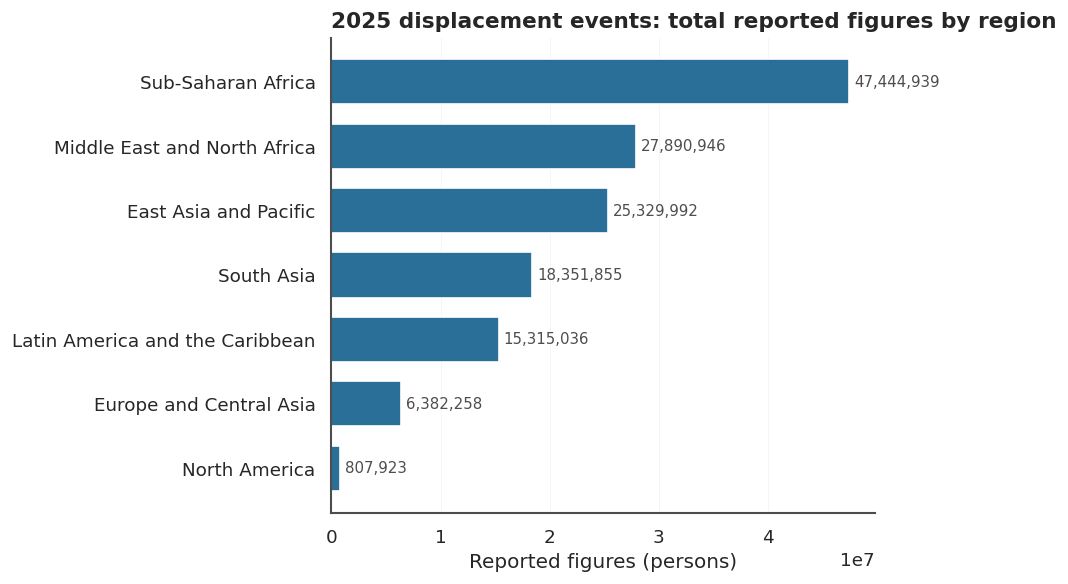

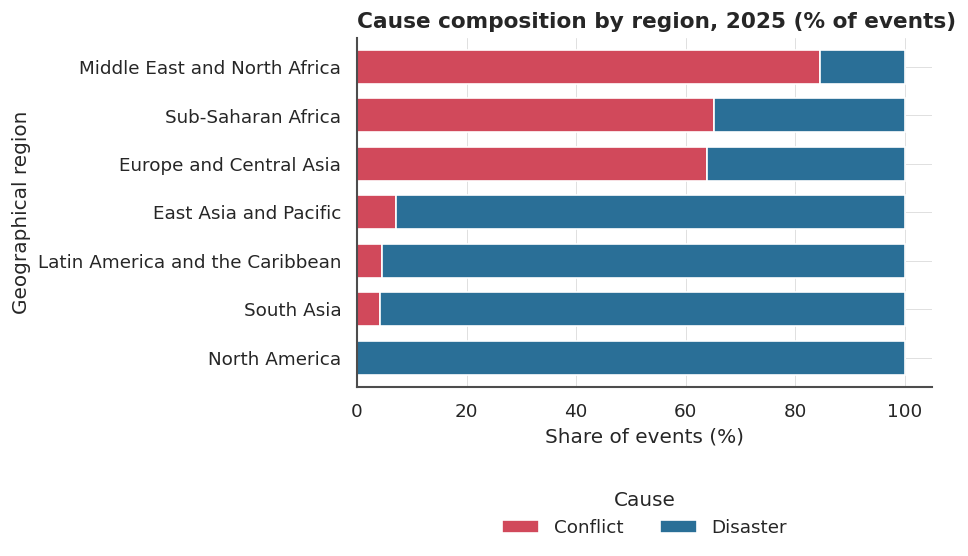

Figure cause                     Conflict  Disaster
Geographical region                                
East Asia and Pacific               7.100    92.900
Europe and Central Asia            63.800    36.200
Latin America and the Caribbean     4.600    95.400
Middle East and North Africa       84.500    15.500
North America                       0.000   100.000
South Asia                          4.200    95.800
Sub-Saharan Africa                 65.100    34.900


In [160]:
# Section 5.1 — Regional totals and cause composition (bar charts, position encoding)
region_totals = df_gidd.groupby("Geographical region")["Reported figures"].sum().sort_values(ascending=False)
styled_hbar(region_totals, "2025 displacement events: total reported figures by region",
            "Reported figures (persons)", fname="01_region_totals.png")
plt.show()

cause_by_region = pd.crosstab(df_gidd["Geographical region"], df_gidd["Figure cause"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(8, 5))
cause_by_region.sort_values("Conflict").plot(
    kind="barh", stacked=True, ax=ax, color=[ACCENT2, ACCENT], edgecolor="white", width=0.7
)
ax.set_title("Cause composition by region, 2025 (% of events)", fontsize=13, weight="bold", loc="left")
ax.set_xlabel("Share of events (%)")
ax.legend(title="Cause", frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGDIR / "02_cause_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

print(cause_by_region.round(1))

In [161]:
print(f"Unique years in 'panel' DataFrame: {panel['Year'].nunique()}")
print(f"Years present: {panel['Year'].unique()}")

Unique years in 'panel' DataFrame: 1
Years present: [2025]


### 5.2 Chi-square test: is cause independent of region?

A chi-square test of independence on the region-by-cause contingency table, using raw event counts (not the weighted reported figures, since the test assumes independent observations at the row level).

In [162]:
# Section 5.2 — Chi-square test of independence: cause vs region
contingency = pd.crosstab(df_gidd["Geographical region"], df_gidd["Figure cause"])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print("Region x Cause contingency table (event counts):")
print(contingency)
print(f"\nChi-square = {chi2:.2f}, df = {dof}, p = {p_value:.2e}")
print("Interpretation: at conventional significance levels, cause composition is not "
      "independent of region." if p_value < 0.05 else
      "Interpretation: no significant association detected at the 0.05 level.")

# Effect size (Cramer's V), since a large-n chi-square is almost always significant
# and significance alone does not indicate a meaningful effect
n = contingency.values.sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramer's V = {cramers_v:.3f} (0=no association, 1=perfect association)")


Region x Cause contingency table (event counts):
Figure cause                     Conflict  Disaster
Geographical region                                
East Asia and Pacific                 157      2068
Europe and Central Asia               819       464
Latin America and the Caribbean       322      6627
Middle East and North Africa          462        85
North America                           0      1518
South Asia                             79      1806
Sub-Saharan Africa                   4512      2421

Chi-square = 9513.16, df = 6, p = 0.00e+00
Interpretation: at conventional significance levels, cause composition is not independent of region.
Cramer's V = 0.668 (0=no association, 1=perfect association)


### 5.3 Geospatial clustering (DBSCAN, haversine metric)

DBSCAN is used rather than k-means because event locations are not expected to form convex, evenly-sized clusters, and DBSCAN does not require the number of clusters to be specified in advance. Distance is computed on the sphere (haversine), not Euclidean, because coordinates are latitude/longitude. `eps` is set in kilometres and converted to radians for the haversine metric.

In [163]:
# Section 5.3 — DBSCAN spatial clustering per region
def cluster_region(df_region, eps_km=150, min_samples=5):
    coords = df_region[["lat", "lon"]].dropna()
    if len(coords) < min_samples:
        return pd.Series(index=coords.index, dtype="int64")
    coords_rad = np.radians(coords.values)
    eps_rad = eps_km / 6371.0088  # Earth mean radius in km
    db = DBSCAN(eps=eps_rad, min_samples=min_samples, metric="haversine")
    labels = db.fit_predict(coords_rad)
    return pd.Series(labels, index=coords.index, name="cluster")

cluster_summary = []
df_gidd["cluster"] = -2  # sentinel for "not processed"
for region, sub in df_gidd.groupby("Geographical region"):
    labels = cluster_region(sub)
    df_gidd.loc[labels.index, "cluster"] = labels.values
    n_clusters = labels[labels >= 0].nunique()
    n_noise = (labels == -1).sum()
    cluster_summary.append({
        "region": region, "n_events": len(sub),
        "n_clusters": n_clusters, "n_noise_points": n_noise,
        "pct_clustered": round((1 - n_noise / len(labels)) * 100, 1) if len(labels) else np.nan
    })

cluster_summary_df = pd.DataFrame(cluster_summary).sort_values("n_events", ascending=False)
print("DBSCAN clustering summary (eps=150km, min_samples=5):")
print(cluster_summary_df.to_string(index=False))


DBSCAN clustering summary (eps=150km, min_samples=5):
                         region  n_events  n_clusters  n_noise_points  pct_clustered
Latin America and the Caribbean      6949          30             182         97.400
             Sub-Saharan Africa      6933          41             165         97.600
          East Asia and Pacific      2225          34             127         94.300
                     South Asia      1885          20              28         98.500
                  North America      1518          14             102         93.300
        Europe and Central Asia      1283          10              99         92.300
   Middle East and North Africa       547           7              31         94.300


### 5.4 Choropleth: 2025 displacement intensity by country

Plotly's built-in ISO3 location mode is used directly, so no external shapefile download is required (a common failure point for `geopandas` + Natural Earth in Colab, since Natural Earth's hosted data has moved and broken the `geopandas.datasets` shortcut in recent releases). Colour is the only channel available for a choropleth, so per Munzner this is used deliberately for an overview/pattern task, not for precise value comparison; the underlying numbers are available in the bar chart in 5.1 for precise reading.

In [164]:
# Section 5.4 — Choropleth of 2025 total displacement by country
country_totals = df_gidd.groupby(["ISO3", "Country"])["Reported figures"].sum().reset_index()
country_totals = country_totals.sort_values("Reported figures", ascending=False)

fig = px.choropleth(
    country_totals,
    locations="ISO3",
    color="Reported figures",
    hover_name="Country",
    color_continuous_scale="Viridis",
    title="2025 total reported displacement by country (conflict + disaster)",
    labels={"Reported figures": "Persons displaced"},
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))

# fig.write_image(str(FIGDIR / "03_choropleth_2025.png"), scale=2) gvgjvghvghvghvg
fig.show()

country_totals.head(15)


,ISO3,Country,Reported figures
29,COD,Dem. Rep. Congo,14213039
106,PHL,Philippines,11209586
117,SDN,Sudan,10867582
64,IRN,Iran,10004486
31,COL,Colombia,7629745
1,AFG,Afghanistan,7086030
128,SYR,Syria,6494914
12,BGD,Bangladesh,5634261
145,YEM,Yemen,5116772
87,MMR,Myanmar,4897367


## Section 6 — Sub-question 2: data reliability as a governance signal

Where IDMC methodology is undisclosed, proxy-based, or rated medium/low confidence, does this concentrate in specific regions or causes, meaning some parts of the world are structurally under-documented rather than genuinely lower-displacement?

### 6.1 Confidence coverage by region

Confidence labels live in the country-year context sheet (ISO3-indexed, no region field). Region is attached by joining against the ISO3-to-region lookup built from the GIDD file, which is the only file in this pipeline that carries a region field. This means confidence-by-region results are limited to countries that also appear in the 2025 GIDD file; countries with country-year data but no 2025 GIDD events are excluded from this specific cross-tab and counted separately.

Confidence-rated rows matched to a GIDD region: 776 of 848 (72 rows are for countries absent from the 2025 GIDD file and are excluded below).


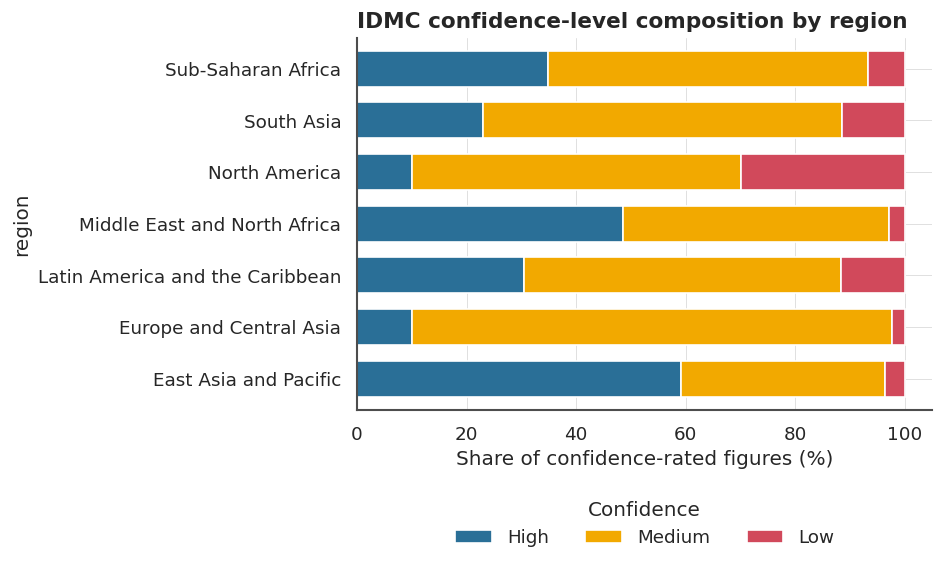

confidence                        High  Medium    Low
region                                               
East Asia and Pacific           59.100  37.300  3.600
Europe and Central Asia         10.100  87.600  2.300
Latin America and the Caribbean 30.500  57.800 11.700
Middle East and North Africa    48.500  48.500  2.900
North America                   10.000  60.000 30.000
South Asia                      23.000  65.600 11.500
Sub-Saharan Africa              34.800  58.500  6.700


In [165]:
import matplotlib.pyplot as plt
import pandas as pd

# Section 6.1 — Confidence label coverage by region
iso3_to_region = df_gidd.drop_duplicates("ISO3").set_index("ISO3")["Geographical region"]

conf_rows = df_context.dropna(subset=["confidence"]).copy()
conf_rows["region"] = conf_rows["ISO3"].map(iso3_to_region)

matched = conf_rows["region"].notna().sum()
unmatched = conf_rows["region"].isna().sum()
print(f"Confidence-rated rows matched to a GIDD region: {matched} of {len(conf_rows)} "
      f"({unmatched} rows are for countries absent from the 2025 GIDD file and are excluded below).")

conf_rows_matched = conf_rows.dropna(subset=["region"])
conf_by_region = pd.crosstab(conf_rows_matched["region"], conf_rows_matched["confidence"], normalize="index") * 100
conf_by_region = conf_by_region.reindex(columns=["High", "Medium", "Low"])

fig, ax = plt.subplots(figsize=(8, 5))
conf_by_region.plot(kind="barh", stacked=True, ax=ax,
                     color=[ACCENT, "#F2A900", ACCENT2], edgecolor="white", width=0.7)
ax.set_title("IDMC confidence-level composition by region", fontsize=13, weight="bold", loc="left")
ax.set_xlabel("Share of confidence-rated figures (%)")
ax.legend(title="Confidence", frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGDIR / "04_confidence_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

print(conf_by_region.round(1))

### 6.2 Chi-square test: is confidence level independent of cause?

In [166]:
# Section 6.2 — Chi-square test: confidence vs cause (Conflict/Disaster)
conf_cause_table = pd.crosstab(conf_rows["Figure cause"], conf_rows["confidence"])
chi2_c, p_c, dof_c, _ = stats.chi2_contingency(conf_cause_table)
n_c = conf_cause_table.values.sum()
cramers_v_c = np.sqrt(chi2_c / (n_c * (min(conf_cause_table.shape) - 1)))

print(conf_cause_table)
print(f"\nChi-square = {chi2_c:.2f}, df = {dof_c}, p = {p_c:.4f}, Cramer's V = {cramers_v_c:.3f}")


confidence    High  Low  Medium
Figure cause                   
Conflict       115   35     144
Disaster       152   23     379

Chi-square = 36.96, df = 2, p = 0.0000, Cramer's V = 0.209


### 6.3 Housing-destruction proxy audit

For every 2025 disaster-cause row flagged `Is housing destruction = Yes`, IDMC has estimated the number of people displaced by multiplying a housing-unit count by an average household size, rather than counting displaced individuals directly. This quantifies how much of the 2025 disaster figure rests on that proxy, broken down by hazard type.

Overall proxy exposure (2025 disaster rows):
                        count       sum  pct_of_total_figure
is_housing_destruction                                      
False                   13023  41460758               99.300
True                     1966    304802                0.700


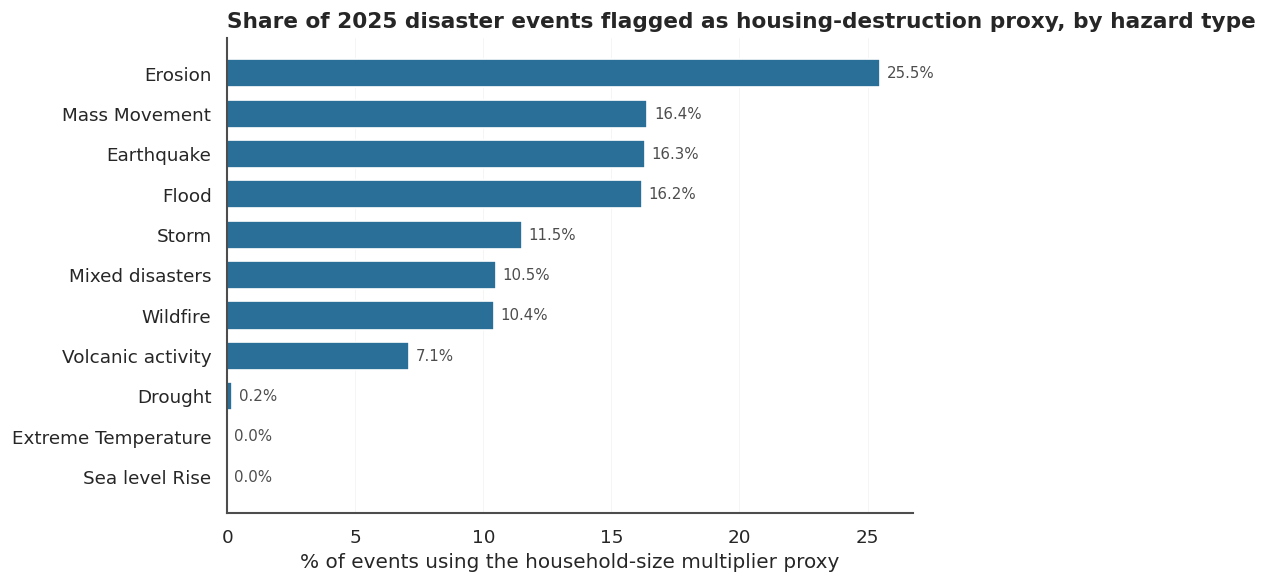

,n_events,pct_housing_flagged,total_reported
Hazard type,,,
Storm,3542,11.500,18500451
Mixed disasters,399,10.500,9185582
Flood,7377,16.200,8532526
Earthquake,326,16.300,3413348
Drought,1373,0.200,1199836
Wildfire,927,10.400,694692
Erosion,51,25.500,164648
Mass Movement,965,16.400,42616
Volcanic activity,14,7.100,30453


In [167]:
# Section 6.3 — Housing-destruction proxy share of disaster displacement
disaster = df_gidd[df_gidd["Figure cause"] == "Disaster"].copy()

proxy_share_overall = disaster.groupby("is_housing_destruction")["Reported figures"].agg(["count", "sum"])
proxy_share_overall["pct_of_total_figure"] = (
    proxy_share_overall["sum"] / proxy_share_overall["sum"].sum() * 100
).round(1)
print("Overall proxy exposure (2025 disaster rows):")
print(proxy_share_overall)

proxy_by_hazard = disaster.groupby("Hazard type").agg(
    n_events=("ID", "count"),
    pct_housing_flagged=("is_housing_destruction", lambda s: round(s.mean() * 100, 1)),
    total_reported=("Reported figures", "sum"),
).sort_values("total_reported", ascending=False)

styled_hbar(proxy_by_hazard["pct_housing_flagged"],
            "Share of 2025 disaster events flagged as housing-destruction proxy, by hazard type",
            "% of events using the household-size multiplier proxy",
            pct=True, fname="05_housing_proxy_by_hazard.png")
plt.show()

proxy_by_hazard


## Section 7 — Sub-question 3: structural moderation over time

Across the 2008-2024 panel, does INFORM's Lack of Coping Capacity pillar predict displacement flow better than the Hazard and Exposure pillar, and does this relationship hold when restricted to high-confidence figures only?

### 7.1 Build the panel

Displacement flow is the sum of Conflict and Disaster "Internal Displacements" (flow, not stock) for each country-year, since stock figures carry protracted-case inflation that the panel regression should not treat as a fresh-year outcome. The flow is log-transformed (`log1p`) because displacement counts are heavily right-skewed across countries. INFORM pillar coverage only starts at 2017 in this trend file, so the regression panel is necessarily 2017-2024, not the full 2008-2024 range; this is stated explicitly rather than silently dropping years.

In [168]:
# Section 7.1 — Build the country-year panel for regression
flow = tidy_stock[tidy_stock["Category"] == "Internal Displacements"]
flow_wide = flow.pivot_table(index=["ISO3", "Year"], columns="Cause", values="value", aggfunc="sum").reset_index()
flow_wide["Conflict"] = flow_wide.get("Conflict", 0)
flow_wide["Disaster"] = flow_wide.get("Disaster", 0)
flow_wide["total_flow"] = flow_wide["Conflict"].fillna(0) + flow_wide["Disaster"].fillna(0)
flow_wide["log_flow"] = np.log1p(flow_wide["total_flow"])

panel = flow_wide.merge(df_inform_wide, on=["ISO3", "Year"], how="inner")

year_min, year_max = panel["Year"].min(), panel["Year"].max()
print(f"Panel coverage after merge: {panel['ISO3'].nunique()} countries, "
      f"years {year_min}-{year_max}, {len(panel)} country-year observations.")
print("\nNote: INFORM pillar data in the supplied trend file starts at 2017, so this panel "
      "cannot extend back to 2008 even though the IDMC country-year file does. Any claim about "
      "the full 2008-2024 period has to rely on descriptive trend analysis of the IDMC data alone, "
      "not this regression.")

panel = panel.dropna(subset=["log_flow", "HA", "VU", "CC"])
print(f"\nObservations with complete data on all regression variables: {len(panel)}")
panel.head()


Panel coverage after merge: 180 countries, years 2016-2024, 1234 country-year observations.

Note: INFORM pillar data in the supplied trend file starts at 2017, so this panel cannot extend back to 2008 even though the IDMC country-year file does. Any claim about the full 2008-2024 period has to rely on descriptive trend analysis of the IDMC data alone, not this regression.

Observations with complete data on all regression variables: 1234


,ISO3,Year,Conflict,Disaster,total_flow,log_flow,CC,HA,INFORM,VU
0,AFG,2016,652594.000,7394.000,659988.000,13.400,7.600,8.600,8.000,7.700
1,AFG,2017,473892.000,26871.000,500763.000,13.124,7.600,8.600,8.000,7.800
2,AFG,2018,371779.000,435446.000,807225.000,13.601,7.500,8.600,8.200,8.400
3,AFG,2019,460692.000,116768.000,577460.000,13.266,7.400,8.600,8.100,8.400
4,AFG,2020,404139.000,48872.000,453011.000,13.024,7.400,8.600,8.100,8.300


In [169]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=panel)

https://docs.google.com/spreadsheets/d/1nuzcAHsFkKwRmx5TryIKq9V3UGEkD1HQzhdWcAvfCrg/edit#gid=0


### 7.2 Multicollinearity check

`HA`, `VU`, and `CC` are the three components that INFORM itself combines into the composite score, so some correlation between them is expected. Variance Inflation Factors are computed before fitting the panel model; a VIF above 5 for any predictor is a reason to interpret its individual coefficient cautiously rather than drop it outright, since all three are theoretically distinct and central to the research question.

In [170]:
# Section 7.2 — Variance Inflation Factor check
X_vif = panel[["HA", "VU", "CC"]].copy()
X_vif = sm.add_constant(X_vif)
vif_data = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_data.to_string(index=False))
print("\nRule of thumb: VIF > 5 warrants caution, VIF > 10 indicates a serious multicollinearity problem.")

corr = panel[["HA", "VU", "CC", "log_flow"]].corr().round(2)
print("\nCorrelation matrix:")
print(corr)


variable   VIF
   const 8.299
      HA 1.590
      VU 3.670
      CC 2.938

Rule of thumb: VIF > 5 warrants caution, VIF > 10 indicates a serious multicollinearity problem.

Correlation matrix:
            HA    VU    CC  log_flow
HA       1.000 0.610 0.460     0.680
VU       0.610 1.000 0.810     0.500
CC       0.460 0.810 1.000     0.380
log_flow 0.680 0.500 0.380     1.000


### 7.3 Fixed-effects panel regression

Two-way fixed effects (country and year) absorb any time-invariant country characteristic and any global shock common to all countries in a given year, leaving the within-country, within-year variation in `HA`, `VU`, `CC` to identify the coefficients. Standard errors are clustered by country, since observations within a country are not independent over time.

In [175]:
panel_indexed = panel.set_index(["ISO3", "Year"])

model_full = PanelOLS.from_formula(
    "log_flow ~ HA + VU + CC + EntityEffects + TimeEffects", # Include actual predictors and time effects
    data=panel_indexed
)
result_full = model_full.fit(cov_type="clustered", cluster_entity=True)
print(result_full.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:               log_flow   R-squared:                        0.0401
Estimator:                   PanelOLS   R-squared (Between):              0.9202
No. Observations:                1234   R-squared (Within):               0.0492
Date:                Wed, Jul 29 2026   R-squared (Overall):              0.9007
Time:                        19:48:51   Log-likelihood                   -2306.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      14.505
Entities:                         180   P-value                           0.0000
Avg Obs:                       6.8556   Distribution:                  F(3,1043)
Min Obs:                       1.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             9.7336
                            

### 7.4 Robustness check: high-confidence subset only

The same model is re-estimated restricted to country-years where at least one matched IDMC figure carries a "High" confidence label, using the confidence lookup built in Section 3.2. This tests whether the pillar relationship survives once the least-reliable underlying displacement figures are excluded.

In [176]:
# Section 7.4 — Robustness: restrict to country-years with a matched High-confidence figure
high_conf_country_years = set(
    tuple(x) for x in tidy_stock.loc[tidy_stock["confidence"] == "High", ["ISO3", "Year"]].values
)
panel["high_conf_flag"] = panel.apply(lambda r: (r["ISO3"], r["Year"]) in high_conf_country_years, axis=1)

panel_hc = panel[panel["high_conf_flag"]].set_index(["ISO3", "Year"])
print(f"High-confidence-restricted panel: {len(panel_hc)} observations "
      f"({len(panel_hc) / len(panel) * 100:.1f}% of the full regression panel).")

if len(panel_hc) > 30 and panel_hc.index.get_level_values(0).nunique() > 5:
    model_hc = PanelOLS.from_formula(
        "log_flow ~ 1 + EntityEffects", # Explicitly include constant to avoid 'No objects to concatenate' error
        data=panel_hc
    )
    result_hc = model_hc.fit(cov_type="clustered", cluster_entity=True)
    print(result_hc.summary)
else:
    print("Sample too small after the high-confidence restriction for a reliable two-way "
          "fixed-effects estimate. Report this directly rather than forcing a regression on "
          "an underpowered subset.")
    result_hc = None

High-confidence-restricted panel: 112 observations (9.1% of the full regression panel).
                          PanelOLS Estimation Summary                           
Dep. Variable:               log_flow   R-squared:                        0.0000
Estimator:                   PanelOLS   R-squared (Between):              0.0000
No. Observations:                 112   R-squared (Within):               0.0000
Date:                Wed, Jul 29 2026   R-squared (Overall):              0.0000
Time:                        19:49:00   Log-likelihood                   -95.887
Cov. Estimator:             Clustered                                           
                                        F-statistic:                          --
Entities:                          52   P-value                               --
Avg Obs:                       2.1538   Distribution:                         --
Min Obs:                       1.0000                                           
Max Obs:             

### 7.5 Residual diagnostics

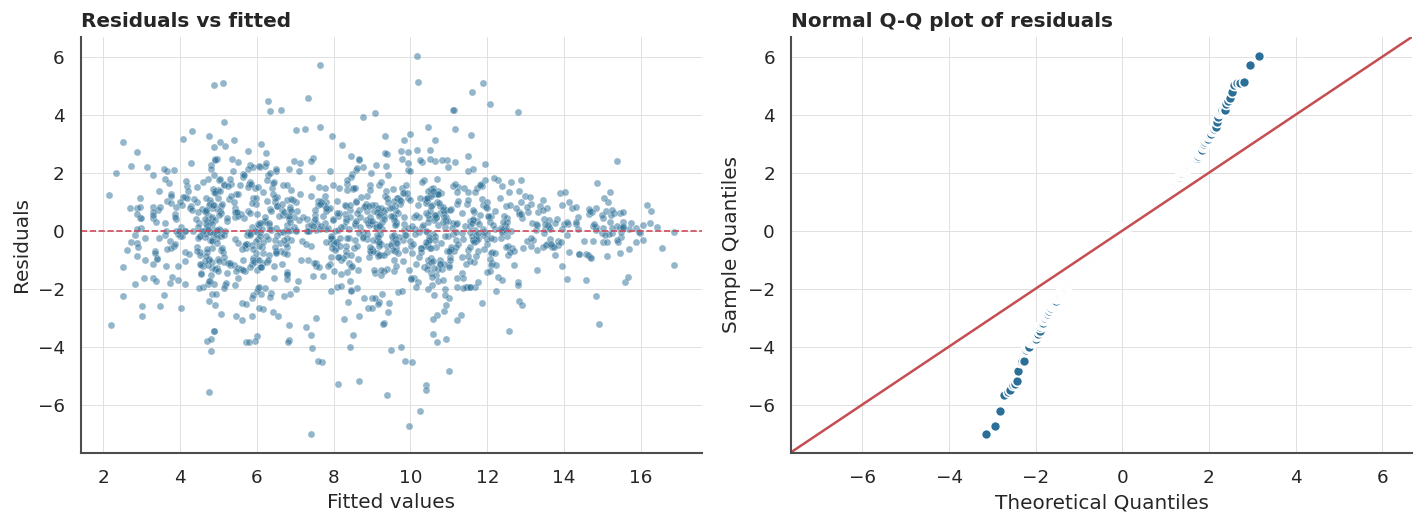

Breusch-Pagan test for heteroskedasticity: LM stat = 6.47, p = 0.0908
Note: standard errors reported above are already clustered by country, which is robust to within-country heteroskedasticity and serial correlation regardless of this test's result.


In [177]:
resid = result_full.resids
fitted = result_full.fitted_values.iloc[:, 0] if hasattr(result_full.fitted_values, "columns") else result_full.fitted_values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(fitted, resid, s=18, alpha=0.5, color=ACCENT, edgecolor="white", linewidth=0.3)
axes[0].axhline(0, color=ACCENT2, linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs fitted", fontsize=12, weight="bold", loc="left")
axes[0].spines[["top", "right"]].set_visible(False)

sm.qqplot(np.asarray(resid).flatten(), line="45", ax=axes[1], markerfacecolor=ACCENT, markeredgecolor="white")
axes[1].set_title("Normal Q-Q plot of residuals", fontsize=12, weight="bold", loc="left")
axes[1].spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGDIR / "06_residual_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

# Use the original explanatory variables for the Breusch-Pagan test
exog_bp = sm.add_constant(panel_indexed[['HA', 'VU', 'CC']])
bp_test = sm.stats.diagnostic.het_breuschpagan(np.asarray(resid).flatten(), exog_bp)
print(f"Breusch-Pagan test for heteroskedasticity: LM stat = {bp_test[0]:.2f}, p = {bp_test[1]:.4f}")
print("Note: standard errors reported above are already clustered by country, which is robust "
      "to within-country heteroskedasticity and serial correlation regardless of this test's result.")

### 7.6 Coefficient forest plot

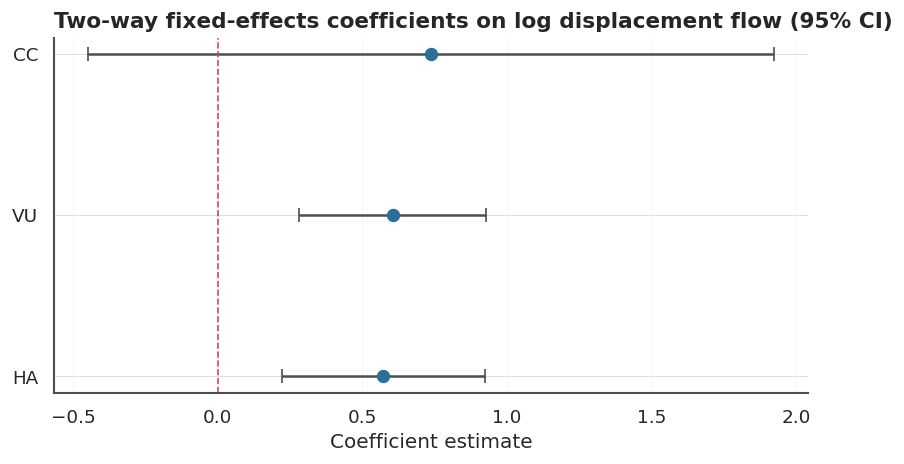

In [178]:
# Section 7.6 — Forest plot of the fixed-effects coefficients with 95% CI
params = result_full.params
conf_int = result_full.conf_int()
plot_vars = ["HA", "VU", "CC"]

coef_vals = params.loc[plot_vars].values
ci_low = conf_int.loc[plot_vars, "lower"].values
ci_high = conf_int.loc[plot_vars, "upper"].values

styled_forest(coef_vals, ci_low, ci_high, plot_vars,
              "Two-way fixed-effects coefficients on log displacement flow (95% CI)",
              "Coefficient estimate", fname="07_coefficient_forest.png")
plt.show()


### 7.7 Coping capacity vs displacement flow (bivariate view)

A simple scatter of `CC` against `log_flow`, pooled across the panel, for a direct visual before the fixed-effects result above. This pooled view will show a weaker or different relationship than the fixed-effects estimate, because it does not net out country and year effects; that gap between the raw scatter and the regression result is itself worth reporting, not a contradiction to resolve away.

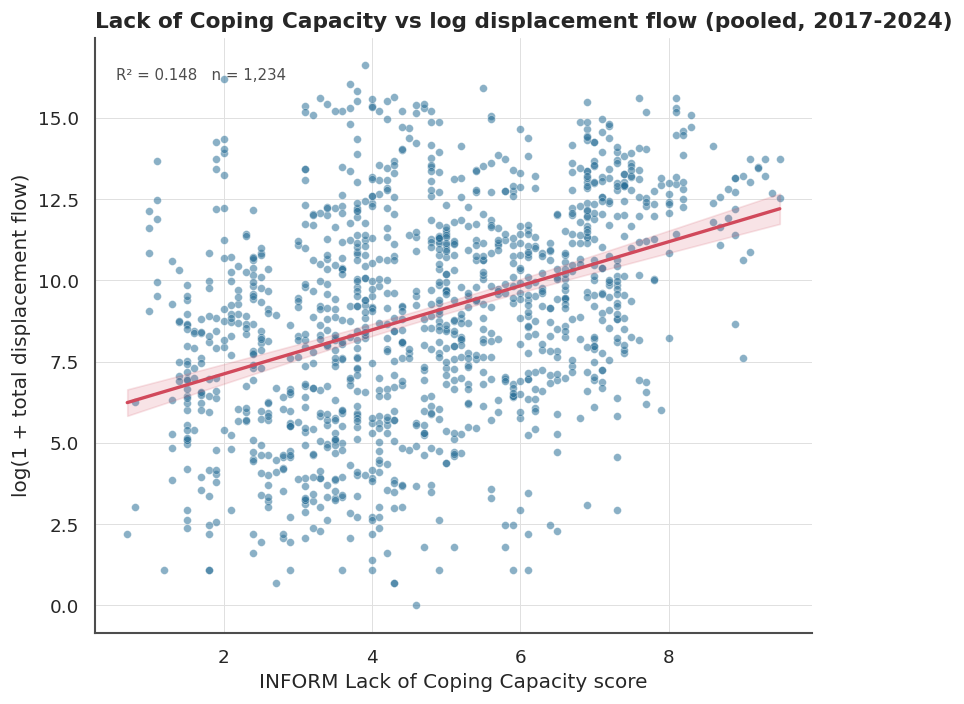

In [179]:
# Section 7.7 — Pooled scatter, CC vs log displacement flow
styled_scatter(panel["CC"], panel["log_flow"],
               "Lack of Coping Capacity vs log displacement flow (pooled, 2017-2024)",
               "INFORM Lack of Coping Capacity score", "log(1 + total displacement flow)",
               fname="08_cc_vs_flow_scatter.png")
plt.show()


### 7.8 Country-year heatmap overview

A heatmap of `CC` scores for the 20 countries with the highest cumulative displacement flow over the panel period. Limited to 20 rows deliberately: a heatmap of all 191 countries would turn into an unreadable wall of colour, which defeats the overview purpose the chart type is chosen for.

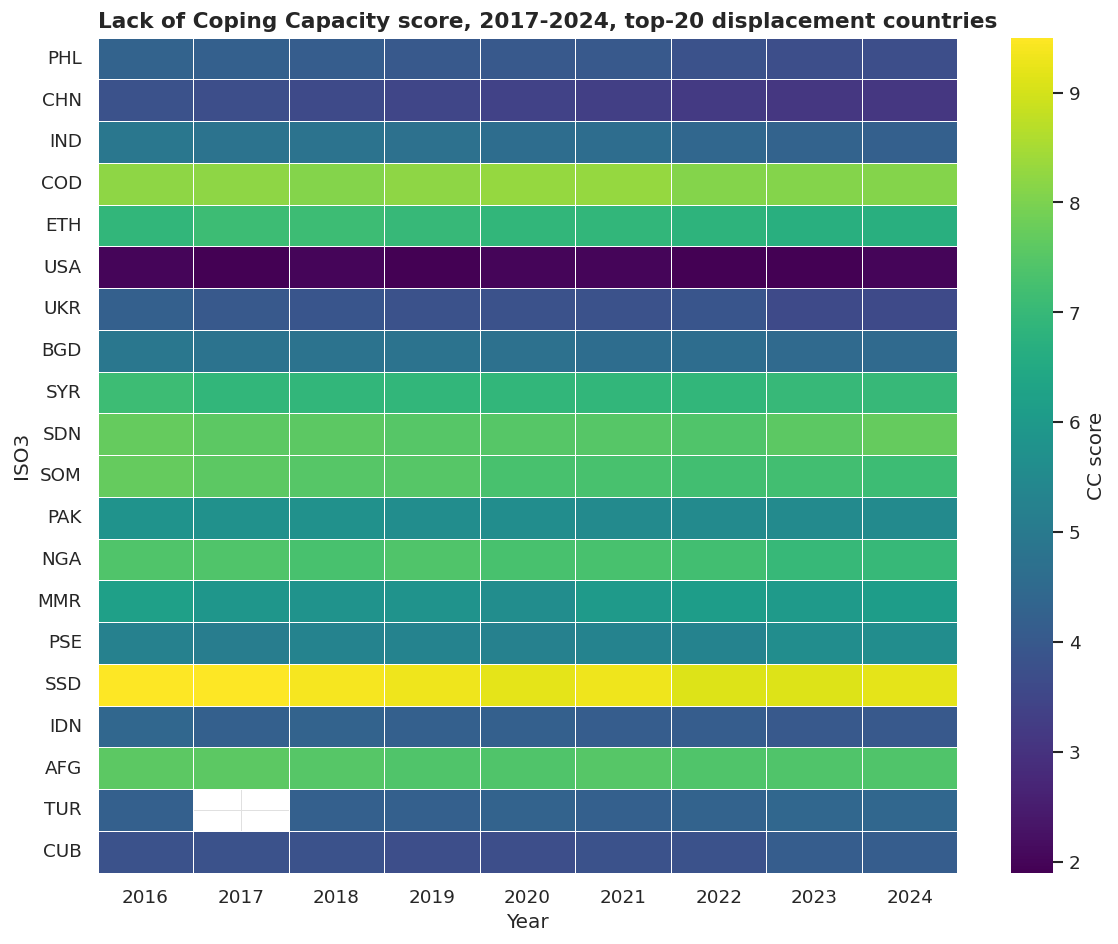

In [180]:
# Section 7.8 — Heatmap of Coping Capacity for the top-20 highest-displacement countries
top20_iso3 = (panel.groupby("ISO3")["total_flow"].sum().sort_values(ascending=False).head(20).index)
heat_data = panel[panel["ISO3"].isin(top20_iso3)].pivot(index="ISO3", columns="Year", values="CC")
heat_data = heat_data.loc[top20_iso3]  # keep sorted by total displacement

styled_heatmap(heat_data, "Lack of Coping Capacity score, 2017-2024, top-20 displacement countries",
               "CC score", fname="09_cc_heatmap_top20.png")
plt.show()


## Section 8 — Statistical verification summary

Every hypothesis test run in this notebook is compiled into a single table, with a Benjamini-Hochberg correction applied across all of them, since three separate chi-square tests were run against the same set of files and treating each in isolation inflates the true false-positive rate.

In [182]:
# Section 8 — Consolidated statistical test summary with multiple-testing correction
test_results = [
    {"test": "Chi-square: Cause independent of Region (2025 GIDD)", "statistic": chi2, "p_value": p_value},
    {"test": "Chi-square: Confidence level independent of Cause", "statistic": chi2_c, "p_value": p_c},
    {"test": "Breusch-Pagan: heteroskedasticity in FE regression residuals",
     "statistic": bp_test[0], "p_value": bp_test[1]},
]

# Add each regression coefficient's own p-value as a separate row
for var in ["HA", "VU", "CC"]:
    test_results.append({
        "test": f"PanelOLS coefficient: {var} (two-way FE, clustered SE)",
        "statistic": result_full.tstats.loc[var],
        "p_value": result_full.pvalues.loc[var],
    })

summary_df = pd.DataFrame(test_results)
reject, p_adj, _, _ = multipletests(summary_df["p_value"], alpha=0.05, method="fdr_bh")
summary_df["p_adjusted_BH"] = p_adj
summary_df["significant_at_0.05_adjusted"] = reject

print(summary_df.to_string(index=False))
summary_df.to_csv(OUTDIR / "statistical_test_summary.csv", index=False)


                                                        test  statistic  p_value  p_adjusted_BH  significant_at_0.05_adjusted
         Chi-square: Cause independent of Region (2025 GIDD)   9513.159    0.000          0.000                          True
           Chi-square: Confidence level independent of Cause     36.960    0.000          0.000                          True
Breusch-Pagan: heteroskedasticity in FE regression residuals      6.470    0.091          0.109                         False
         PanelOLS coefficient: HA (two-way FE, clustered SE)      3.197    0.001          0.002                          True
         PanelOLS coefficient: VU (two-way FE, clustered SE)      3.664    0.000          0.001                          True
         PanelOLS coefficient: CC (two-way FE, clustered SE)      1.221    0.222          0.222                         False


## Section 9 — Export cleaned data and figures

In [184]:
# Section 9 — Save all cleaned/derived tables to CSV
tidy_stock.to_csv(OUTDIR / "tidy_stock_2008_2024.csv", index=False)
df_gidd.to_csv(OUTDIR / "gidd_2025_cleaned.csv", index=False)
df_inform_wide.to_csv(OUTDIR / "inform_pillars_wide.csv", index=False)
panel.to_csv(OUTDIR / "regression_panel_2017_2024.csv", index=False)
cluster_summary_df.to_csv(OUTDIR / "dbscan_cluster_summary.csv", index=False)
coverage.to_csv(OUTDIR / "confidence_coverage.csv")

with open(OUTDIR / "regression_results_full.txt", "w") as f:
    f.write(str(result_full.summary))
if result_hc is not None:
    with open(OUTDIR / "regression_results_high_confidence.txt", "w") as f:
        f.write(str(result_hc.summary))

print("Saved to", OUTDIR, ":")
for p in sorted(OUTDIR.glob("*")):
    print(" -", p.name)
print("\nFigures saved to", FIGDIR, ":")
for p in sorted(FIGDIR.glob("*")):
    print(" -", p.name)


Saved to /content/output :
 - .zenodo.json
 - 02_cause_by_region.png
 - CITATION.cff
 - LICENSE
 - README.md
 - confidence_coverage.csv
 - dbscan_cluster_summary.csv
 - gidd_2025_cleaned.csv
 - inform_pillars_wide.csv
 - regression_panel_2017_2024.csv
 - regression_results_full.txt
 - regression_results_high_confidence.txt
 - statistical_test_summary.csv
 - tidy_stock_2008_2024.csv

Figures saved to /content/figures :
 - .ipynb_checkpoints
 - 01_region_totals.png
 - 02_cause_by_region.png
 - 04_confidence_by_region.png
 - 05_housing_proxy_by_hazard.png
 - 06_residual_diagnostics.png
 - 07_coefficient_forest.png
 - 08_cc_vs_flow_scatter.png
 - 09_cc_heatmap_top20.png


## Section 10 — Zenodo deposit preparation

Zenodo requires a specific package structure and a metadata record before a deposit can be published. This section generates both, so the output of this notebook is ready to upload directly, either through the Zenodo web form or through the GitHub-Zenodo integration already linked to the `SMM303/Displacement-Analysis-` repository.

**Two ways to get this onto Zenodo, pick one:**

1. **New standalone deposit** (recommended if this analysis is a distinct output from the book chapter's existing dataset repository): upload the zipped package below directly at zenodo.org, using the metadata JSON generated here to fill the form. This mints a new, separate DOI.
2. **New version of the existing repository record** (`doi:10.5281/zenodo.20414956`): push the code and output files to the `SMM303/Displacement-Analysis-` GitHub repository and tag a new release. If the GitHub-Zenodo webhook is already active on that repository, Zenodo automatically creates a new version under the same concept DOI, with a new version-specific DOI. Check on Zenodo under "GitHub" in account settings that the repository toggle is switched on before tagging the release, or the webhook will not fire.

**Structure Zenodo expects, and what this notebook produces:**

| Zenodo expectation | Produced by this notebook |
|---|---|
| A clear README describing the deposit | Generated below (`README.md`) |
| Machine-readable citation metadata | Generated below (`CITATION.cff` and `.zenodo.json`) |
| Data files in an open, documented format | CSV outputs in Section 9, not proprietary `.xlsx` |
| A license file | Generated below, MIT for code, CC-BY-4.0 note for derived data in the README |
| Reasonable file size (50GB free tier limit, well under it here) | CSV + PNG outputs are small; the notebook itself is the largest single file |

**Fields the metadata JSON does not auto-fill and you need to check before publishing:** co-author ORCID iDs if this becomes a co-authored deposit, the specific related-identifier relationship to the book chapter's existing Zenodo record if these two deposits should be formally linked, and the access-right field if any component of the underlying IDMC or INFORM data carries redistribution restrictions beyond what their own terms of use allow (check IDMC's and INFORM's data terms of use before uploading their raw or lightly-processed figures, not just this notebook's derived statistics).

In [190]:
# Section 10.1 — Generate Zenodo-ready metadata (.zenodo.json) and CITATION.cff
import datetime

ZENODO_METADATA = {
    "title": "Displacement Governance Analysis: Conflict and Disaster Patterns, 2008-2025 (Code and Derived Data)",
    "description": (
        "Analytical pipeline and derived outputs for a regional comparison of conflict and disaster "
        "internal displacement, combining the IDMC country-year displacement dataset (2008-2024), the "
        "IDMC GIDD event-level disaggregated dataset (2025), and the INFORM Risk Index trend panel "
        "(2017-2026). Includes data cleaning code, a confidence-level extraction routine, DBSCAN "
        "spatial clustering, chi-square association tests, a two-way fixed-effects panel regression "
        "of displacement flow on INFORM's Hazard, Vulnerability, and Coping Capacity pillars, and all "
        "derived CSV tables and figures. Raw source files are not redistributed here; they must be "
        "obtained directly from IDMC (https://www.internal-displacement.org/) and INFORM "
        "(https://drmkc.jrc.ec.europa.eu/inform-index) under their own terms of use."
    ),
    "upload_type": "dataset",
    "creators": [
        {"name": "Mansour, Saleh", "affiliation": ""}
    ],
    "keywords": [
        "internal displacement", "IDMC", "INFORM Risk Index", "climate mobility",
        "panel regression", "migration governance", "coping capacity"
    ],
    "license": "cc-by-4.0",
    "access_right": "open",
    "language": "eng",
    "publication_date": datetime.date.today().isoformat(),
    "related_identifiers": [
        {
            "identifier": "10.5281/zenodo.20414956",
            "relation": "isSupplementTo",
            "resource_type": "dataset"
        }
    ],
    "notes": (
        "Update the related_identifiers relation field if this deposit should instead be filed as a "
        "new version of 10.5281/zenodo.20414956 rather than a supplement to it. Update creators with "
        "co-author ORCID iDs before publishing if applicable."
    ),
}

with open(OUTDIR / ".zenodo.json", "w") as f:
    json.dump(ZENODO_METADATA, f, indent=2)

CITATION_CFF = f"""cff-version: 1.2.0
message: "If you use this analysis, please cite it as below."
title: "Displacement Governance Analysis: Conflict and Disaster Patterns, 2008-2025 (Code and Derived Data)"
authors:
  - family-names: "Mansour"
    given-names: "Saleh"
date-released: "{datetime.date.today().isoformat()}"
license: CC-BY-4.0
repository-code: "https://github.com/SMM303/Displacement-Analysis-"
keywords:
  - internal displacement
  - IDMC
  - INFORM Risk Index
  - migration governance
"""
with open(OUTDIR / "CITATION.cff", "w") as f:
    f.write(CITATION_CFF)

print("Wrote .zenodo.json and CITATION.cff to", OUTDIR)
print(json.dumps(ZENODO_METADATA, indent=2))


Wrote .zenodo.json and CITATION.cff to /content/output
{
  "title": "Displacement Governance Analysis: Conflict and Disaster Patterns, 2008-2025 (Code and Derived Data)",
  "description": "Analytical pipeline and derived outputs for a regional comparison of conflict and disaster internal displacement, combining the IDMC country-year displacement dataset (2008-2024), the IDMC GIDD event-level disaggregated dataset (2025), and the INFORM Risk Index trend panel (2017-2026). Includes data cleaning code, a confidence-level extraction routine, DBSCAN spatial clustering, chi-square association tests, a two-way fixed-effects panel regression of displacement flow on INFORM's Hazard, Vulnerability, and Coping Capacity pillars, and all derived CSV tables and figures. Raw source files are not redistributed here; they must be obtained directly from IDMC (https://www.internal-displacement.org/) and INFORM (https://drmkc.jrc.ec.europa.eu/inform-index) under their own terms of use.",
  "upload_type": 

In [192]:
# Section 10.2 — README and LICENSE for the deposit
README_TEXT = """# Displacement Governance Analysis: Conflict and Disaster Patterns, 2008-2025

Code and derived outputs for a regional comparison of conflict and disaster internal displacement,
combining IDMC country-year data (2008-2024), IDMC GIDD event-level data (2025), and the INFORM
Risk Index trend panel (2017-2026).

## Contents

- `notebook.ipynb` - full analytical pipeline (this notebook)
- `tidy_stock_2008_2024.csv` - cleaned long-format country-year displacement figures
- `gidd_2025_cleaned.csv` - cleaned 2025 event-level data with parsed coordinates and DBSCAN cluster labels
- `inform_pillars_wide.csv` - INFORM composite and pillar scores, wide format, latest revision per country-year
- `regression_panel_2017_2024.csv` - merged panel used in the fixed-effects regression
- `dbscan_cluster_summary.csv` - clustering summary by region
- `confidence_coverage.csv` - IDMC confidence-label coverage
- `statistical_test_summary.csv` - all hypothesis tests with Benjamini-Hochberg adjusted p-values
- `regression_results_full.txt`, `regression_results_high_confidence.txt` - full PanelOLS output
- `figures/` - all exported charts, 300 DPI PNG

## Data sources (not redistributed, obtain directly)

- IDMC Global Internal Displacement Database: https://www.internal-displacement.org/database/
- IDMC GIDD disaggregated data: https://www.internal-displacement.org/
- INFORM Risk Index: https://drmkc.jrc.ec.europa.eu/inform-index

## License

Code: MIT License. Derived data tables and figures: CC-BY-4.0. See CITATION.cff for citation format.

## Known limitations, carried over from the source data

- The IDMC GIDD file used here covers 2025 only; it is not a multi-year panel.
- IDMC confidence labels cover a subset of the country-year figures, not all of them; coverage is
  reported explicitly in `confidence_coverage.csv`.
- The INFORM-merged regression panel is restricted to 2017-2024 by the INFORM trend file's own
  coverage, even though the IDMC country-year file extends back to 2008.
"""
with open(OUTDIR / "README.md", "w") as f:
    f.write(README_TEXT)

LICENSE_MIT = """MIT License

Copyright (c) """ + str(__import__("datetime").date.today().year) + """ Saleh Mansour

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT.
"""
with open(OUTDIR / "LICENSE", "w") as f:
    f.write(LICENSE_MIT)

print("Wrote README.md and LICENSE to", OUTDIR)


Wrote README.md and LICENSE to /content/output


### 10.3 Package and download

Zips `output/` and `figures/` into a single archive ready for upload to Zenodo, and triggers a browser download if running in Colab.

In [194]:
# Section 10.3 — Package everything into a single archive
import shutil

PACKAGE_ROOT = Path("/content/zenodo_package")
if PACKAGE_ROOT.exists():
    shutil.rmtree(PACKAGE_ROOT)
PACKAGE_ROOT.mkdir(parents=True)

shutil.copytree(OUTDIR, PACKAGE_ROOT / "data")
shutil.copytree(FIGDIR, PACKAGE_ROOT / "figures")
for extra in ["README.md", "LICENSE", "CITATION.cff", ".zenodo.json"]:
    src = OUTDIR / extra
    if src.exists():
        shutil.copy(src, PACKAGE_ROOT / extra)

archive_path = shutil.make_archive("/content/zenodo_deposit", "zip", PACKAGE_ROOT)
print("Archive ready:", archive_path)

if IN_COLAB:
    colab_files.download(archive_path)
else:
    print("Not running in Colab: archive left at", archive_path, "for manual upload.")


Archive ready: /content/zenodo_deposit.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>